In [1]:
# =========================
# CELL 1: Imports
# =========================

import os
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from torchvision import transforms
from PIL import Image

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_curve,
)

from tqdm.notebook import tqdm

# Handcrafted feature libs
from skimage.feature import local_binary_pattern, hog
import cv2
from scipy.signal import convolve2d

# timm will be used later in the model cell (Xception / ResNet)
import timm


/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` 

In [2]:
# =========================
# CELL 2: BSIF Filters & BSIF Function
# =========================

def generate_bsif_filters(filter_size=7, num_bits=8):
    """Generate BSIF filters (7x7, 8 filters)."""
    bsif_filters_7x7_8bit = np.array([
        [[-0.02, -0.01,  0.01,  0.02,  0.01, -0.01, -0.02],
         [-0.03, -0.02,  0.00,  0.03,  0.00, -0.02, -0.03],
         [-0.02, -0.01,  0.02,  0.04,  0.02, -0.01, -0.02],
         [-0.01,  0.00,  0.03,  0.05,  0.03,  0.00, -0.01],
         [-0.02, -0.01,  0.02,  0.04,  0.02, -0.01, -0.02],
         [-0.03, -0.02,  0.00,  0.03,  0.00, -0.02, -0.03],
         [-0.02, -0.01,  0.01,  0.02,  0.01, -0.01, -0.02]],

        [[ 0.01,  0.02,  0.02,  0.01,  0.02,  0.02,  0.01],
         [ 0.02,  0.03,  0.03,  0.01,  0.03,  0.03,  0.02],
         [ 0.02,  0.03,  0.04,  0.02,  0.04,  0.03,  0.02],
         [ 0.01,  0.01,  0.02,  0.00,  0.02,  0.01,  0.01],
         [-0.02, -0.03, -0.04,  0.02, -0.04, -0.03, -0.02],
         [-0.02, -0.03, -0.03,  0.01, -0.03, -0.03, -0.02],
         [-0.01, -0.02, -0.02,  0.01, -0.02, -0.02, -0.01]],

        [[ 0.00,  0.01,  0.01,  0.02,  0.01,  0.01,  0.00],
         [ 0.01,  0.02,  0.02,  0.03,  0.02,  0.02,  0.01],
         [ 0.01,  0.02,  0.03,  0.04,  0.03,  0.02,  0.01],
         [ 0.02,  0.03,  0.04,  0.05,  0.04,  0.03,  0.02],
         [-0.01, -0.02, -0.03, -0.04, -0.03, -0.02, -0.01],
         [-0.01, -0.02, -0.02, -0.03, -0.02, -0.02, -0.01],
         [ 0.00, -0.01, -0.01, -0.02, -0.01, -0.01,  0.00]],

        [[-0.01, -0.01,  0.00,  0.01,  0.00, -0.01, -0.01],
         [-0.01, -0.01,  0.01,  0.02,  0.01, -0.01, -0.01],
         [ 0.00,  0.01,  0.02,  0.03,  0.02,  0.01,  0.00],
         [ 0.01,  0.02,  0.03,  0.04,  0.03,  0.02,  0.01],
         [ 0.00,  0.01,  0.02,  0.03,  0.02,  0.01,  0.00],
         [-0.01, -0.01,  0.01,  0.02,  0.01, -0.01, -0.01],
         [-0.01, -0.01,  0.00,  0.01,  0.00, -0.01, -0.01]],

        [[ 0.02,  0.01,  0.00, -0.01,  0.00,  0.01,  0.02],
         [ 0.01,  0.00, -0.01, -0.02, -0.01,  0.00,  0.01],
         [ 0.00, -0.01, -0.02, -0.03, -0.02, -0.01,  0.00],
         [-0.01, -0.02, -0.03, -0.04, -0.03, -0.02, -0.01],
         [ 0.00, -0.01, -0.02, -0.03, -0.02, -0.01,  0.00],
         [ 0.01,  0.00, -0.01, -0.02, -0.01,  0.00,  0.01],
         [ 0.02,  0.01,  0.00, -0.01,  0.00,  0.01,  0.02]],

        [[ 0.01,  0.02,  0.01,  0.00,  0.01,  0.02,  0.01],
         [ 0.00,  0.01,  0.00, -0.01,  0.00,  0.01,  0.00],
         [-0.01,  0.00, -0.01, -0.02, -0.01,  0.00, -0.01],
         [-0.02, -0.01, -0.02, -0.03, -0.02, -0.01, -0.02],
         [-0.01,  0.00, -0.01, -0.02, -0.01,  0.00, -0.01],
         [ 0.00,  0.01,  0.00, -0.01,  0.00,  0.01,  0.00],
         [ 0.01,  0.02,  0.01,  0.00,  0.01,  0.02,  0.01]],

        [[-0.02, -0.01,  0.00,  0.01,  0.00, -0.01, -0.02],
         [-0.01,  0.00,  0.01,  0.02,  0.01,  0.00, -0.01],
         [ 0.00,  0.01,  0.02,  0.03,  0.02,  0.01,  0.00],
         [ 0.01,  0.02,  0.03,  0.04,  0.03,  0.02,  0.01],
         [ 0.00,  0.01,  0.02,  0.03,  0.02,  0.01,  0.00],
         [-0.01,  0.00,  0.01,  0.02,  0.01,  0.00, -0.01],
         [-0.02, -0.01,  0.00,  0.01,  0.00, -0.01, -0.02]],

        [[ 0.00,  0.00,  0.01,  0.01,  0.01,  0.00,  0.00],
         [ 0.00,  0.01,  0.02,  0.02,  0.02,  0.01,  0.00],
         [ 0.01,  0.02,  0.03,  0.03,  0.03,  0.02,  0.01],
         [ 0.01,  0.02,  0.03,  0.04,  0.03,  0.02,  0.01],
         [ 0.01,  0.02,  0.03,  0.03,  0.03,  0.02,  0.01],
         [ 0.00,  0.01,  0.02,  0.02,  0.02,  0.01,  0.00],
         [ 0.00,  0.00,  0.01,  0.01,  0.01,  0.00,  0.00]]
    ], dtype=np.float32)

    return bsif_filters_7x7_8bit


def apply_bsif(image_gray, num_bits=8):
    """Apply BSIF to a grayscale image (H,W) -> BSIF code (H,W) as float32."""
    filters = generate_bsif_filters(filter_size=7, num_bits=num_bits)

    # Ensure float32 (assume values already in a reasonable range, e.g. [0,1])
    if image_gray.dtype != np.float32:
        image_gray = image_gray.astype(np.float32)

    responses = []
    for i in range(num_bits):
        response = convolve2d(image_gray, filters[i], mode='same', boundary='symm')
        binary_response = (response > 0).astype(np.uint8)
        responses.append(binary_response)

    bsif_code = np.zeros_like(image_gray, dtype=np.uint8)
    for i, response in enumerate(responses):
        bsif_code += response * (2 ** i)

    return bsif_code.astype(np.float32)


In [3]:
# =========================
# CELL 3 — FIXED DATASET WITH NORMALIZED FEATURES (PREVENTS NaN)
# =========================

class MorphDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.image_paths = []
        self.labels = []
        
        bona_fide_dir = os.path.join(root_dir, 'Bona fide')
        morph_dir = os.path.join(root_dir, 'Morph')
        
        for label, class_dir in enumerate([bona_fide_dir, morph_dir]):
            for img_name in os.listdir(class_dir):
                img_path = os.path.join(class_dir, img_name)
                self.image_paths.append(img_path)
                self.labels.append(label)
    
    def __len__(self):
        return len(self.image_paths)
    
    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        image = Image.open(img_path).convert('RGB')
        label = self.labels[idx]
        
        if self.transform:
            image_t = self.transform(image)
        else:
            image_t = transforms.ToTensor()(image)

        image_np = np.array(image_t.permute(1,2,0))  # HWC

        # ---------- LBP ----------
        lbp_channels = []
        for i in range(3):
            ch = image_np[:,:,i]
            lbp = local_binary_pattern(ch, P=8, R=1, method="uniform")
            lbp_channels.append(lbp)

        lbp_image = np.stack(lbp_channels, axis=0).astype(np.float32)
        lbp_image = (lbp_image - lbp_image.min()) / (lbp_image.max() - lbp_image.min() + 1e-6)
        lbp_image = torch.tensor(lbp_image, dtype=torch.float32)

        # ---------- HOG ----------
        _, hog_image = hog(
            image_np,
            pixels_per_cell=(16,16),
            cells_per_block=(2,2),
            orientations=9,
            visualize=True,
            channel_axis=-1
        )
        hog_image = hog_image.astype(np.float32)
        hog_image = (hog_image - hog_image.min()) / (hog_image.max() - hog_image.min() + 1e-6)
        hog_image = torch.tensor(hog_image, dtype=torch.float32).unsqueeze(0)

        # ---------- BSIF ----------
        image_gray = cv2.cvtColor(image_np, cv2.COLOR_RGB2GRAY)
        bsif_im = apply_bsif(image_gray, num_bits=8).astype(np.float32)
        bsif_im = (bsif_im - bsif_im.mean()) / (bsif_im.std() + 1e-6)  # Standardization is safer
        bsif_im = torch.tensor(bsif_im, dtype=torch.float32).unsqueeze(0)

        return image_t, lbp_image, hog_image, bsif_im, label


In [4]:
# =========================
# CELL 4: Transforms
# =========================

transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],  # ImageNet mean
        std=[0.229, 0.224, 0.225]    # ImageNet std
    ),
])


In [5]:
# =========================
# CELL 5: Dataset Loading & DataLoaders
# =========================

train_dataset = MorphDataset(
    root_dir='/kaggle/input/mad-data2/Test/Dataset/Train',
    transform=transform
)

val_dataset = MorphDataset(
    root_dir='/kaggle/input/mad-data2/Test/Dataset/Validation',
    transform=transform
)

test_dataset = MorphDataset(
    root_dir='/kaggle/input/mad-data2/Test/Dataset/Test',
    transform=transform
)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=4)
val_loader   = DataLoader(val_dataset, batch_size=16, shuffle=False, num_workers=4)
test_loader  = DataLoader(test_dataset, batch_size=16, shuffle=False, num_workers=4)

print("Dataset sizes:")
print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))
print("Test:", len(test_dataset))


Dataset sizes:
Train: 11200
Validation: 1600
Test: 3200


In [6]:
# =========================
# CELL 6: Dual-Stream UNet (Xception + ResNet50) 
#         with Multi-Level Fusion (Option 2)
# =========================

import timm
import torch.nn.functional as F

class DualStreamUNetXcepRes50(nn.Module):
    def __init__(self, num_classes=2):
        super(DualStreamUNetXcepRes50, self).__init__()

        # -----------------------------
        # 1. Encoders (Xception + ResNet50)
        # -----------------------------
        # Both take 5-channel handcrafted input: [3 LBP + 1 HOG + 1 BSIF]
        self.xcep_encoder = timm.create_model(
            'xception',
            pretrained=True,
            features_only=True,
            in_chans=5
        )
        self.resnet_encoder = timm.create_model(
            'resnet50',
            pretrained=True,
            features_only=True,
            in_chans=5
        )

        # Get feature channel sizes from timm
        x_chs = self.xcep_encoder.feature_info.channels()   # e.g. [64, 128, 256, 728, 2048]
        r_chs = self.resnet_encoder.feature_info.channels() # e.g. [64, 256, 512, 1024, 2048]

        self.x_chs = x_chs
        self.r_chs = r_chs

        # -----------------------------
        # 2. UNet Decoder for Xception branch
        # -----------------------------
        self.x_up1  = nn.ConvTranspose2d(x_chs[4], x_chs[3], kernel_size=2, stride=2)
        self.x_dec1 = nn.Conv2d(x_chs[3] + x_chs[3], x_chs[3], kernel_size=3, padding=1)

        self.x_up2  = nn.ConvTranspose2d(x_chs[3], x_chs[2], kernel_size=2, stride=2)
        self.x_dec2 = nn.Conv2d(x_chs[2] + x_chs[2], x_chs[2], kernel_size=3, padding=1)

        self.x_up3  = nn.ConvTranspose2d(x_chs[2], x_chs[1], kernel_size=2, stride=2)
        self.x_dec3 = nn.Conv2d(x_chs[1] + x_chs[1], x_chs[1], kernel_size=3, padding=1)

        self.x_up4  = nn.ConvTranspose2d(x_chs[1], x_chs[0], kernel_size=2, stride=2)
        self.x_dec4 = nn.Conv2d(x_chs[0] + x_chs[0], x_chs[0], kernel_size=3, padding=1)

        self.x_final = nn.Conv2d(x_chs[0], 5, kernel_size=3, padding=1)  # reconstruct 5 channels

        # -----------------------------
        # 3. UNet Decoder for ResNet50 branch
        # -----------------------------
        self.r_up1  = nn.ConvTranspose2d(r_chs[4], r_chs[3], kernel_size=2, stride=2)
        self.r_dec1 = nn.Conv2d(r_chs[3] + r_chs[3], r_chs[3], kernel_size=3, padding=1)

        self.r_up2  = nn.ConvTranspose2d(r_chs[3], r_chs[2], kernel_size=2, stride=2)
        self.r_dec2 = nn.Conv2d(r_chs[2] + r_chs[2], r_chs[2], kernel_size=3, padding=1)

        self.r_up3  = nn.ConvTranspose2d(r_chs[2], r_chs[1], kernel_size=2, stride=2)
        self.r_dec3 = nn.Conv2d(r_chs[1] + r_chs[1], r_chs[1], kernel_size=3, padding=1)

        self.r_up4  = nn.ConvTranspose2d(r_chs[1], r_chs[0], kernel_size=2, stride=2)
        self.r_dec4 = nn.Conv2d(r_chs[0] + r_chs[0], r_chs[0], kernel_size=3, padding=1)

        self.r_final = nn.Conv2d(r_chs[0], 5, kernel_size=3, padding=1)  # reconstruct 5 channels

        # -----------------------------
        # 4. Multi-level Fusion (Option 2)
        #    - Xception bottleneck (enc5_x)
        #    - ResNet bottleneck (enc5_r)
        #    - Xception residual map (5ch)
        #    - ResNet residual map (5ch)
        # -----------------------------
        self.gap = nn.AdaptiveAvgPool2d((1, 1))

        fused_dim = x_chs[4] + r_chs[4] + 5 + 5  # enc5_x + enc5_r + pooled_res_x + pooled_res_r

        self.classifier = nn.Sequential(
            nn.Linear(fused_dim, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )

    def _decode_xception(self, enc1, enc2, enc3, enc4, enc5, target_size):
        # Xception UNet decoder
        d4 = self.x_up1(enc5)
        e4 = F.interpolate(enc4, size=d4.shape[2:], mode='bilinear', align_corners=False)
        d4 = torch.cat([d4, e4], dim=1)
        d4 = F.relu(self.x_dec1(d4))

        d3 = self.x_up2(d4)
        e3 = F.interpolate(enc3, size=d3.shape[2:], mode='bilinear', align_corners=False)
        d3 = torch.cat([d3, e3], dim=1)
        d3 = F.relu(self.x_dec2(d3))

        d2 = self.x_up3(d3)
        e2 = F.interpolate(enc2, size=d2.shape[2:], mode='bilinear', align_corners=False)
        d2 = torch.cat([d2, e2], dim=1)
        d2 = F.relu(self.x_dec3(d2))

        d1 = self.x_up4(d2)
        e1 = F.interpolate(enc1, size=d1.shape[2:], mode='bilinear', align_corners=False)
        d1 = torch.cat([d1, e1], dim=1)
        d1 = F.relu(self.x_dec4(d1))

        recon = self.x_final(d1)
        recon = F.interpolate(recon, size=target_size, mode='bilinear', align_corners=False)
        return recon

    def _decode_resnet(self, enc1, enc2, enc3, enc4, enc5, target_size):
        # ResNet50 UNet decoder
        d4 = self.r_up1(enc5)
        e4 = F.interpolate(enc4, size=d4.shape[2:], mode='bilinear', align_corners=False)
        d4 = torch.cat([d4, e4], dim=1)
        d4 = F.relu(self.r_dec1(d4))

        d3 = self.r_up2(d4)
        e3 = F.interpolate(enc3, size=d3.shape[2:], mode='bilinear', align_corners=False)
        d3 = torch.cat([d3, e3], dim=1)
        d3 = F.relu(self.r_dec2(d3))

        d2 = self.r_up3(d3)
        e2 = F.interpolate(enc2, size=d2.shape[2:], mode='bilinear', align_corners=False)
        d2 = torch.cat([d2, e2], dim=1)
        d2 = F.relu(self.r_dec3(d2))

        d1 = self.r_up4(d2)
        e1 = F.interpolate(enc1, size=d1.shape[2:], mode='bilinear', align_corners=False)
        d1 = torch.cat([d1, e1], dim=1)
        d1 = F.relu(self.r_dec4(d1))

        recon = self.r_final(d1)
        recon = F.interpolate(recon, size=target_size, mode='bilinear', align_corners=False)
        return recon

    def forward(self, image_t, lbp, hog, bsif):
        """
        image_t: (N,3,H,W)  - normalized RGB (kept for future use / ablations)
        lbp    : (N,3,H,W)
        hog    : (N,1,H,W)
        bsif   : (N,1,H,W)
        """
        # -----------------------------
        # 1. Build 5-channel handcrafted input
        # -----------------------------
        x_in = torch.cat([lbp, hog, bsif], dim=1)   # (N,5,H,W)

        # -----------------------------
        # 2. Xception branch (encoder)
        # -----------------------------
        x_feats = self.xcep_encoder(x_in)
        x_enc1, x_enc2, x_enc3, x_enc4, x_enc5 = x_feats

        # -----------------------------
        # 3. ResNet50 branch (encoder)
        # -----------------------------
        r_feats = self.resnet_encoder(x_in)
        r_enc1, r_enc2, r_enc3, r_enc4, r_enc5 = r_feats

        # -----------------------------
        # 4. Decoders -> Reconstructions
        # -----------------------------
        target_size = x_in.shape[2:]  # (H,W)

        x_recon = self._decode_xception(x_enc1, x_enc2, x_enc3, x_enc4, x_enc5, target_size)
        r_recon = self._decode_resnet(r_enc1, r_enc2, r_enc3, r_enc4, r_enc5, target_size)

        # -----------------------------
        # 5. Residual maps (handcrafted - reconstruction)
        # -----------------------------
        x_residual = x_in - x_recon   # (N,5,H,W)
        r_residual = x_in - r_recon   # (N,5,H,W)

        # -----------------------------
        # 6. Multi-level Fusion (enc5 + residuals)
        # -----------------------------
        # Global Average Pooling
        x_bottleneck_vec = self.gap(x_enc5).flatten(1)      # (N, x_chs[4])
        r_bottleneck_vec = self.gap(r_enc5).flatten(1)      # (N, r_chs[4])
        x_res_vec        = self.gap(x_residual).flatten(1)  # (N, 5)
        r_res_vec        = self.gap(r_residual).flatten(1)  # (N, 5)

        fused = torch.cat(
            [x_bottleneck_vec, r_bottleneck_vec, x_res_vec, r_res_vec],
            dim=1
        )  # (N, fused_dim)

        logits = self.classifier(fused)

        return x_recon, r_recon, x_residual, r_residual, logits


# Initialize model and move to device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = DualStreamUNetXcepRes50(num_classes=2).to(device)

print("Dual-Stream model initialized on:", device)
print("Xception feature channels:", model.x_chs)
print("ResNet50 feature channels:", model.r_chs)


/usr/local/lib/python3.11/dist-packages/timm/models/_factory.py:138: UserWarning: Mapping deprecated model name xception to current legacy_xception.
  model = create_fn(
Downloading: "https://github.com/rwightman/pytorch-image-models/releases/download/v0.1-cadene/xception-43020ad28.pth" to /root/.cache/torch/hub/checkpoints/xception-43020ad28.pth


model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]

Dual-Stream model initialized on: cuda
Xception feature channels: [64, 128, 256, 728, 2048]
ResNet50 feature channels: [64, 256, 512, 1024, 2048]


/usr/local/lib/python3.11/dist-packages/skimage/feature/texture.py:385: UserWarning: Applying `local_binary_pattern` to floating-point images may give unexpected results when small numerical differences between adjacent pixels are present. It is recommended to use this function with images of integer dtype.
  warnings.warn(


Random sample index: 7505, Label: 1


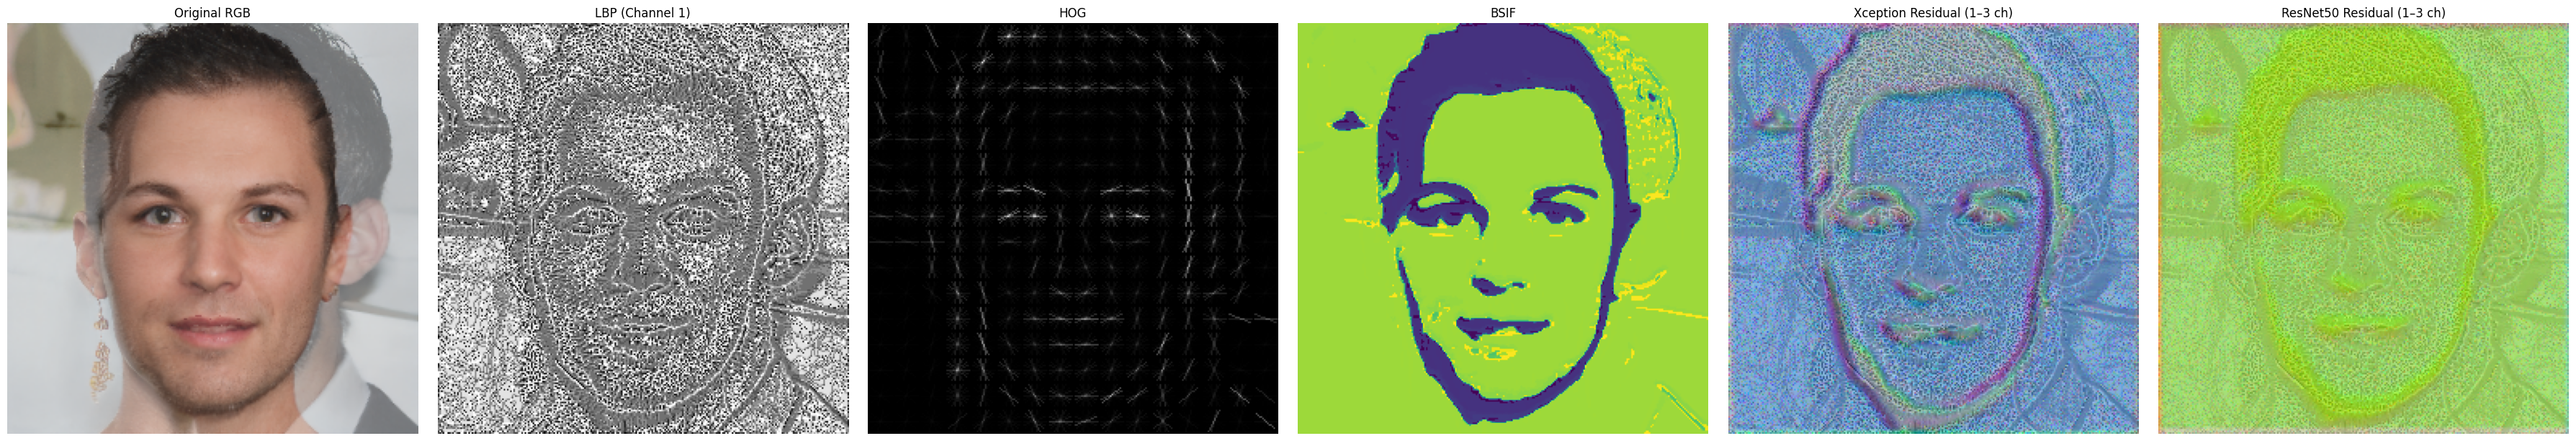

Logits: [[-0.00494071 -0.02285057]]
Probabilities: [0.5044774  0.49552268]
Predicted class: 0 (0 = Bona fide, 1 = Morph)
True label: 1


In [7]:
# =========================
# CELL 7: Visualization for Dual-Stream Model
# =========================

import random
import matplotlib.pyplot as plt

# 1) Pick a random sample from the train dataset
random_idx = random.randint(0, len(train_dataset) - 1)
image_t, lbp_image, hog_image, bsif_image, label = train_dataset[random_idx]

print(f"Random sample index: {random_idx}, Label: {label}")

# 2) Add batch dimension
image_b = image_t.unsqueeze(0).to(device)      # (1,3,H,W)
lbp_b   = lbp_image.unsqueeze(0).to(device)    # (1,3,H,W)
hog_b   = hog_image.unsqueeze(0).to(device)    # (1,1,H,W)
bsif_b  = bsif_image.unsqueeze(0).to(device)   # (1,1,H,W)

model.eval()

with torch.no_grad():
    x_recon, r_recon, x_residual, r_residual, logits = model(
        image_b, lbp_b, hog_b, bsif_b
    )

# 3) Denormalize original RGB image for display
def denormalize(tensor_3chw: torch.Tensor) -> torch.Tensor:
    """
    tensor_3chw: (3,H,W), normalized with ImageNet stats
    returns: (3,H,W) in [0,1]
    """
    mean = torch.tensor([0.485, 0.456, 0.406], device=tensor_3chw.device).view(3, 1, 1)
    std  = torch.tensor([0.229, 0.224, 0.225], device=tensor_3chw.device).view(3, 1, 1)
    tensor = tensor_3chw * std + mean
    return tensor.clamp(0.0, 1.0)

orig_denorm = denormalize(image_t.to(device)).cpu()

# 4) Prepare tensors for visualization

# Remove batch dimension
x_recon_vis   = x_recon.squeeze(0).cpu()      # (5,H,W)
r_recon_vis   = r_recon.squeeze(0).cpu()      # (5,H,W)
x_res_vis     = x_residual.squeeze(0).cpu()   # (5,H,W)
r_res_vis     = r_residual.squeeze(0).cpu()   # (5,H,W)

lbp_vis   = lbp_image.cpu()   # (3,H,W)
hog_vis   = hog_image.cpu()   # (1,H,W)
bsif_vis  = bsif_image.cpu()  # (1,H,W)

# Helper for converting feature maps to uint8 images
def to_uint8(tensor):
    """
    tensor: (C,H,W) or (H,W)
    returns: uint8 tensor in [0,255]
    """
    t = tensor.clone()
    t = t - t.min()
    if t.max() > 0:
        t = t / t.max()
    t = (t * 255).byte()
    return t

from torchvision.transforms.functional import to_pil_image

orig_pil = to_pil_image(orig_denorm)

# Use first 3 channels of residuals for visualization
x_res_pil = to_pil_image(to_uint8(x_res_vis[:3]))
r_res_pil = to_pil_image(to_uint8(r_res_vis[:3]))

# For recon we could also visualize first 3 channels if desired
x_recon_pil = to_pil_image(to_uint8(x_recon_vis[:3]))

# 5) Plot: Original, LBP (ch1), HOG, BSIF, Xception Residual, ResNet Residual
fig, axes = plt.subplots(1, 6, figsize=(36, 6))

axes[0].imshow(orig_pil)
axes[0].set_title("Original RGB")
axes[0].axis("off")

# LBP channel 1
axes[1].imshow(lbp_vis[0].numpy(), cmap="gray")
axes[1].set_title("LBP (Channel 1)")
axes[1].axis("off")

# HOG
axes[2].imshow(hog_vis.squeeze(0).numpy(), cmap="gray")
axes[2].set_title("HOG")
axes[2].axis("off")

# BSIF
axes[3].imshow(bsif_vis.squeeze(0).numpy(), cmap="viridis")
axes[3].set_title("BSIF")
axes[3].axis("off")

# Xception residual
axes[4].imshow(x_res_pil)
axes[4].set_title("Xception Residual (1–3 ch)")
axes[4].axis("off")

# ResNet50 residual
axes[5].imshow(r_res_pil)
axes[5].set_title("ResNet50 Residual (1–3 ch)")
axes[5].axis("off")

plt.tight_layout()
plt.show()

# 6) Print classification result
probs = torch.softmax(logits, dim=1).cpu().squeeze(0)
pred_class = torch.argmax(probs).item()

print("Logits:", logits.cpu().numpy())
print("Probabilities:", probs.numpy())
print("Predicted class:", pred_class, "(0 = Bona fide, 1 = Morph)")
print("True label:", label)


In [8]:
# =========================
# CELL 8: Training Loop (Dual-Stream Dual-UNet Model) with Progress Logs + NaN Guard
# =========================

import torch.optim as optim
import matplotlib.pyplot as plt
from torch.cuda.amp import GradScaler, autocast
import time

# Re-initialize the dual-stream model
model = DualStreamUNetXcepRes50(num_classes=2).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', patience=3, verbose=True
)

scaler = GradScaler()

num_epochs = 25
patience = 5
best_val_loss = float('inf')
patience_counter = 0

train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []


def train(model, device, train_loader, optimizer, epoch, accumulation_steps=4):
    model.train()
    train_loss = 0.0
    correct = 0
    start_time = time.time()

    optimizer.zero_grad()

    for batch_idx, (data, lbp, hog, bsif, target) in enumerate(train_loader):
        data   = data.to(device)
        lbp    = lbp.to(device)
        hog    = hog.to(device)
        bsif   = bsif.to(device)
        target = target.to(device)

        with autocast():
            x_recon, r_recon, x_residual, r_residual, logits = model(
                data, lbp, hog, bsif
            )
            loss = criterion(logits, target)

        # NaN / Inf guard
        if torch.isnan(loss) or torch.isinf(loss):
            print(f"[Epoch {epoch} | Batch {batch_idx}] WARNING: NaN/Inf loss, skipping this batch.")
            continue

        loss_for_backward = loss / accumulation_steps
        scaler.scale(loss_for_backward).backward()

        # ✅ Only unscale + clip + step when we actually STEP
        if (batch_idx + 1) % accumulation_steps == 0 or (batch_idx + 1) == len(train_loader):
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)

            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad()

        train_loss += loss.item()
        pred = logits.argmax(dim=1, keepdim=True)
        correct += pred.eq(target.view_as(pred)).sum().item()

        if batch_idx % 10 == 0:
            elapsed = time.time() - start_time
            print(
                f"Train Epoch: {epoch} "
                f"[{batch_idx * len(data)}/{len(train_loader.dataset)} "
                f"({100. * batch_idx / len(train_loader):.0f}%)]\t"
                f"Loss: {loss.item():.6f}\tElapsed: {elapsed:.2f}s"
            )

    train_loss /= len(train_loader)
    accuracy = 100.0 * correct / len(train_loader.dataset)
    return train_loss, accuracy


def validate(model, device, val_loader):
    model.eval()
    val_loss = 0.0
    correct = 0
    start_time = time.time()

    with torch.no_grad():
        for batch_idx, (data, lbp, hog, bsif, target) in enumerate(val_loader):
            data   = data.to(device)
            lbp    = lbp.to(device)
            hog    = hog.to(device)
            bsif   = bsif.to(device)
            target = target.to(device)

            with autocast():
                x_recon, r_recon, x_residual, r_residual, logits = model(
                    data, lbp, hog, bsif
                )
                loss = criterion(logits, target)

            if torch.isnan(loss) or torch.isinf(loss):
                print(f"[VAL | Batch {batch_idx}] WARNING: NaN/Inf loss, skipping.")
                continue

            val_loss += loss.item()
            pred = logits.argmax(dim=1, keepdim=True)
            correct += pred.eq(target.view_as(pred)).sum().item()

            if batch_idx % 10 == 0:
                elapsed = time.time() - start_time
                print(
                    f"Validation: [{batch_idx * len(data)}/{len(val_loader.dataset)} "
                    f"({100. * batch_idx / len(val_loader):.0f}%)]\t"
                    f"Loss: {loss.item():.6f}\tElapsed: {elapsed:.2f}s"
                )

    val_loss /= len(val_loader)
    accuracy = 100.0 * correct / len(val_loader.dataset)
    return val_loss, accuracy


for epoch in range(1, num_epochs + 1):
    print(f"\n=== Starting epoch {epoch}/{num_epochs} ===")
    start_time = time.time()

    train_loss, train_acc = train(model, device, train_loader, optimizer, epoch)
    val_loss, val_acc = validate(model, device, val_loader)
    scheduler.step(val_loss)

    epoch_time = time.time() - start_time

    train_losses.append(train_loss)
    train_accuracies.append(train_acc)
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    print(
        f"Epoch {epoch}: "
        f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}% | "
        f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}% | "
        f"Time: {epoch_time:.2f}s"
    )

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), "best_dualstream_model.pth")
        print("  -> Best model saved.")
    else:
        patience_counter += 1
        print(f"  -> Patience counter: {patience_counter}/{patience}")
        if patience_counter >= patience:
            print(f"Early stopping triggered after {epoch} epochs.")
            break

model.load_state_dict(torch.load("best_dualstream_model.pth"))
print("Best model loaded from best_dualstream_model.pth")



=== Starting epoch 1/25 ===


/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(
/tmp/ipykernel_20/373282663.py:19: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
/tmp/ipykernel_20/373282663.py:47: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Train Epoch: 1 [0/11200 (0%)]	Loss: 0.708069	Elapsed: 5.96s
Train Epoch: 1 [160/11200 (1%)]	Loss: 0.814819	Elapsed: 15.62s
Train Epoch: 1 [320/11200 (3%)]	Loss: 0.490921	Elapsed: 28.84s
Train Epoch: 1 [480/11200 (4%)]	Loss: 0.190466	Elapsed: 39.16s
Train Epoch: 1 [640/11200 (6%)]	Loss: 0.166908	Elapsed: 52.55s
Train Epoch: 1 [800/11200 (7%)]	Loss: 0.022591	Elapsed: 62.80s
Train Epoch: 1 [960/11200 (9%)]	Loss: 0.037983	Elapsed: 75.79s
Train Epoch: 1 [1120/11200 (10%)]	Loss: 0.016647	Elapsed: 86.16s
Train Epoch: 1 [1280/11200 (11%)]	Loss: 0.004081	Elapsed: 99.14s
Train Epoch: 1 [1440/11200 (13%)]	Loss: 0.012164	Elapsed: 109.44s
Train Epoch: 1 [1600/11200 (14%)]	Loss: 0.025468	Elapsed: 122.35s
Train Epoch: 1 [1760/11200 (16%)]	Loss: 0.721058	Elapsed: 132.54s
Train Epoch: 1 [1920/11200 (17%)]	Loss: 0.005725	Elapsed: 145.87s
Train Epoch: 1 [2080/11200 (19%)]	Loss: 0.803452	Elapsed: 156.19s
Train Epoch: 1 [2240/11200 (20%)]	Loss: 0.581645	Elapsed: 169.18s
Train Epoch: 1 [2400/11200 (21%)]	Lo

/tmp/ipykernel_20/373282663.py:102: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Validation: [0/1600 (0%)]	Loss: 0.001566	Elapsed: 4.84s
Validation: [160/1600 (10%)]	Loss: 0.000025	Elapsed: 13.99s
Validation: [320/1600 (20%)]	Loss: 0.002689	Elapsed: 26.99s
Validation: [480/1600 (30%)]	Loss: 0.000072	Elapsed: 36.16s
Validation: [640/1600 (40%)]	Loss: 0.000180	Elapsed: 49.11s
Validation: [800/1600 (50%)]	Loss: 0.000037	Elapsed: 58.17s
Validation: [960/1600 (60%)]	Loss: 0.000132	Elapsed: 71.08s
Validation: [1120/1600 (70%)]	Loss: 0.000000	Elapsed: 80.17s
Validation: [1280/1600 (80%)]	Loss: 0.000147	Elapsed: 93.06s
Validation: [1440/1600 (90%)]	Loss: 0.000035	Elapsed: 102.02s
Epoch 1: Train Loss: 0.0590, Train Acc: 97.29% | Val Loss: 0.0024, Val Acc: 99.94% | Time: 925.91s
  -> Best model saved.

=== Starting epoch 2/25 ===
Train Epoch: 2 [0/11200 (0%)]	Loss: 0.022100	Elapsed: 5.04s
Train Epoch: 2 [160/11200 (1%)]	Loss: 0.001871	Elapsed: 15.43s
Train Epoch: 2 [320/11200 (3%)]	Loss: 0.000022	Elapsed: 28.76s
Train Epoch: 2 [480/11200 (4%)]	Loss: 0.000018	Elapsed: 39.29s


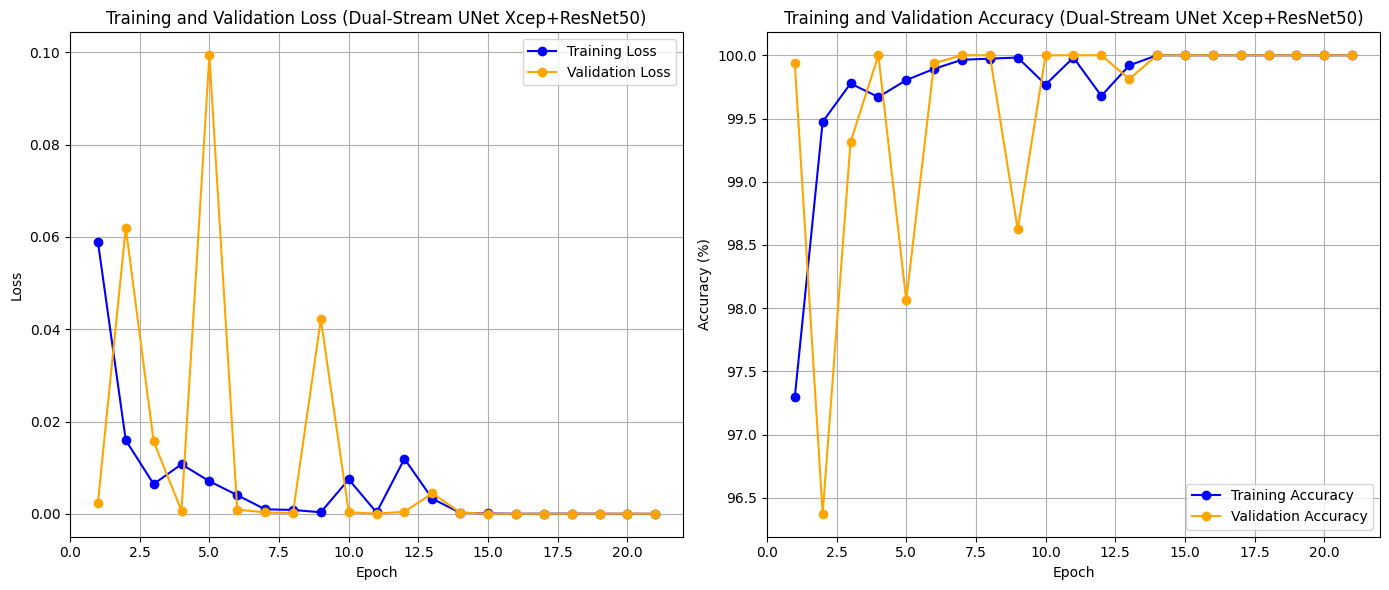

In [9]:
# =========================
# CELL 9: Plot Training & Validation Curves (Dual-Stream)
# =========================

epochs = range(1, len(train_losses) + 1)

plt.figure(figsize=(14, 6))

# ---- Loss subplot ----
plt.subplot(1, 2, 1)
plt.plot(epochs, train_losses, 'b-o', label='Training Loss')
plt.plot(epochs, val_losses, color='orange', marker='o', label='Validation Loss')
plt.title('Training and Validation Loss (Dual-Stream UNet Xcep+ResNet50)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid(True)

# ---- Accuracy subplot ----
plt.subplot(1, 2, 2)
plt.plot(epochs, train_accuracies, 'b-o', label='Training Accuracy')
plt.plot(epochs, val_accuracies, color='orange', marker='o', label='Validation Accuracy')
plt.title('Training and Validation Accuracy (Dual-Stream UNet Xcep+ResNet50)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend(loc='lower right')
plt.grid(True)

plt.tight_layout()
plt.show()


In [10]:
# =========================
# CELL 10: Evaluation (Dual-Stream Model)
# =========================

from sklearn.metrics import roc_curve, confusion_matrix
from sklearn.metrics import precision_score, recall_score, f1_score
import numpy as np

def calculate_bpcer(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    if cm.shape != (2, 2):
        print("Warning: confusion matrix is not 2x2, got:", cm.shape)
        return 0.0
    false_negatives = cm[0, 1]
    total_genuine = cm[0, 0] + cm[0, 1]
    bpcer = false_negatives / total_genuine if total_genuine > 0 else 0.0
    return bpcer

def calculate_eer(y_true, y_scores):
    fpr, tpr, thresholds = roc_curve(y_true, y_scores)
    fnr = 1 - tpr
    idx = np.nanargmin(np.absolute(fnr - fpr))
    eer_threshold = thresholds[idx]
    eer = fpr[idx]
    return eer, eer_threshold

def calculate_deer(y_true, y_scores):
    fpr, tpr, thresholds = roc_curve(y_true, y_scores)
    fnr = 1 - tpr
    idx = np.nanargmin(np.absolute(fnr - fpr))
    deer_threshold = thresholds[idx]
    deer = fpr[idx]
    return deer, deer_threshold

def test(model, device, test_loader):
    model.eval()
    test_loss = 0.0
    correct = 0
    all_preds = []
    all_labels = []
    all_scores = []   # scores for positive class (morph)

    with torch.no_grad():
        for data, lbp, hog, bsif, target in test_loader:
            data   = data.to(device)
            lbp    = lbp.to(device)
            hog    = hog.to(device)
            bsif   = bsif.to(device)
            target = target.to(device)

            with autocast():
                # Forward: dual-stream model returns 5 outputs
                x_recon, r_recon, x_residual, r_residual, logits = model(
                    data, lbp, hog, bsif
                )
                loss = criterion(logits, target)

            test_loss += loss.item()
            pred = logits.argmax(dim=1, keepdim=True)
            correct += pred.eq(target.view_as(pred)).sum().item()

            all_preds.extend(pred.view(-1).cpu().numpy())
            all_labels.extend(target.cpu().numpy())
            # Use logit of class 1 (morph) as score
            all_scores.extend(logits[:, 1].cpu().numpy())

    test_loss /= len(test_loader)
    accuracy = 100.0 * correct / len(test_loader.dataset)

    precision = precision_score(all_labels, all_preds, average='weighted', zero_division=0)
    recall    = recall_score(all_labels, all_preds, average='weighted', zero_division=0)
    f1        = f1_score(all_labels, all_preds, average='weighted', zero_division=0)

    cm = confusion_matrix(all_labels, all_preds)
    print("Confusion Matrix:\n", cm)

    return test_loss, accuracy, precision, recall, f1, all_labels, all_preds, all_scores

# ---- Run evaluation on test set ----
test_loss, test_accuracy, test_precision, test_recall, test_f1, all_labels, all_preds, all_scores = test(
    model, device, test_loader
)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.2f}%")
print(f"Test Precision: {test_precision:.4f}")
print(f"Test Recall: {test_recall:.4f}")
print(f"Test F1-Score: {test_f1:.4f}")

# BPCER
bpcer = calculate_bpcer(all_labels, all_preds)
print(f"BPCER: {bpcer:.4f}")

# EER
eer, eer_threshold = calculate_eer(all_labels, all_scores)
print(f"EER: {eer:.4f}, EER Threshold: {eer_threshold:.4f}")

# D-EER
deer, deer_threshold = calculate_deer(all_labels, all_scores)
print(f"D-EER: {deer:.4f}, D-EER Threshold: {deer_threshold:.4f}")


/tmp/ipykernel_20/101915156.py:51: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Confusion Matrix:
 [[1504   96]
 [   0 1600]]
Test Loss: 0.2178
Test Accuracy: 97.00%
Test Precision: 0.9717
Test Recall: 0.9700
Test F1-Score: 0.9700
BPCER: 0.0600
EER: 0.0112, EER Threshold: 5.1367
D-EER: 0.0112, D-EER Threshold: 5.1367
